# 06 · Weekly Revenue Forecasting

**Goal:** forecast company revenue for the next quarter and **prove** the forecast is better than simple rules.

> 📘 **Why this matters for HSBC Finance:** "Planning & Forecasting" is one of the listed job types, and the JD asks for *"demonstrated skills in modelling, forecasting and optimization"*. Finance teams forecast revenue, costs, liquidity and balances every month. The core discipline is the same: **baseline → model → backtest → communicate uncertainty**.

**Approach**
1. Aggregate to **weekly** revenue (daily is too noisy; monthly gives only 24 points).
2. **Hold out** the last 13 weeks (one quarter, Sep-Dec 2011) as a test period the models never see.
3. Compare simple **baselines** with a **harmonic regression** model.
4. Refit on all data and forecast the next 13 weeks **with prediction intervals**.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROCESSED = ROOT / "data" / "processed"
FIGS = ROOT / "reports" / "figures"
sns.set_theme(style="whitegrid")

sales = pd.read_parquet(PROCESSED / "sales_clean.parquet")
# All sales (incl. unknown customers): this is company revenue
weekly = sales.set_index("InvoiceDate")["Revenue"].resample("W-SUN").sum()
weekly = weekly.iloc[:-1]  # last week is incomplete (data ends Fri 9-Dec-2011)
print(f"{len(weekly)} weeks: {weekly.index[0].date()} → {weekly.index[-1].date()}")

105 weeks: 2009-12-06 → 2011-12-04


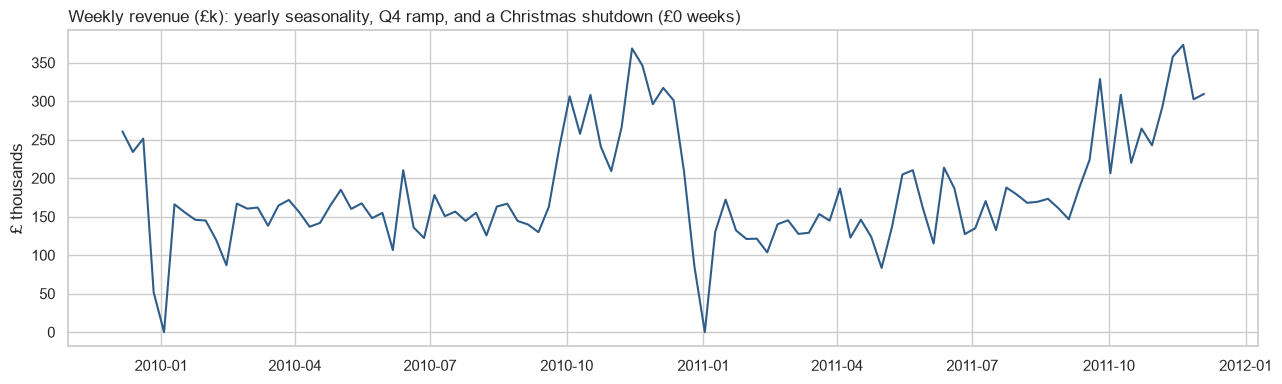

In [2]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(weekly.index, weekly / 1e3, color="#2F5D8A")
ax.set_title("Weekly revenue (£k): yearly seasonality, Q4 ramp, and a Christmas shutdown (£0 weeks)", loc="left")
ax.set_ylabel("£ thousands")
plt.tight_layout(); plt.savefig(FIGS / "06_weekly_revenue.png", dpi=150); plt.show()

**What we see:** a clear **yearly cycle** (Q4 peak), a mild **upward trend**, and **zero-revenue weeks** at Christmas/New Year (the business shuts). Any good model must capture all three.

## 1. Train / test split (time-ordered!)
⚠️ With time series you **never shuffle**. You train on the past and test on the future, exactly as the forecast will be used.

In [3]:
H = 13
train, test = weekly.iloc[:-H], weekly.iloc[-H:]
print(f"Train: {train.index[0].date()} → {train.index[-1].date()} ({len(train)} weeks)")
print(f"Test:  {test.index[0].date()} → {test.index[-1].date()} ({len(test)} weeks)")

Train: 2009-12-06 → 2011-09-04 (92 weeks)
Test:  2011-09-11 → 2011-12-04 (13 weeks)


## 2. Baselines
| Baseline | Rule |
|---|---|
| **Naive** | every future week = last observed week |
| **Seasonal naive** | each week = same week last year |
| **Seasonal naive × growth** | same week last year × recent year-on-year growth rate |

📘 **Error metrics:**
- **MAPE:** mean absolute % error per week (easy to explain: "on average we're off by X%").
- **WAPE:** total absolute error ÷ total actual; more robust when some weeks are small.
- **Bias:** forecast total vs actual total (do we systematically over/under-forecast?). Finance teams care a lot about this.

In [4]:
def metrics(actual, fc):
    actual, fc = np.asarray(actual), np.asarray(fc)
    return {"MAPE %": np.mean(np.abs(actual - fc) / actual) * 100,
            "WAPE %": np.abs(actual - fc).sum() / actual.sum() * 100,
            "Bias %": (fc.sum() / actual.sum() - 1) * 100}

lag52 = weekly.shift(52)
growth = train.iloc[-13:].sum() / lag52.loc[train.index[-13:]].sum()
print(f"Recent YoY growth (last 13 train weeks vs same weeks last year): {growth - 1:+.1%}")

forecasts = {
    "Naive": np.repeat(train.iloc[-1], H),
    "Seasonal naive": lag52.loc[test.index].values,
    "Seasonal naive × growth": lag52.loc[test.index].values * growth,
}

Recent YoY growth (last 13 train weeks vs same weeks last year): +7.9%


## 3. Harmonic regression (trend + Fourier seasonality + shutdown flag)
> 📘 **Fourier terms** describe a yearly cycle with smooth sine/cosine waves: `sin(2πk·t/365)`, `cos(2πk·t/365)` for k = 1…K. Small K = a smooth, simple seasonal shape; larger K = more wiggles. This lets a plain **linear regression** (OLS) learn seasonality from only 2 years of data. Classic models like SARIMA or Holt-Winters need more history to learn a 52-week pattern reliably.
>
> We add a **linear trend** and a **dummy variable** for the Christmas shutdown weeks.

**Choosing K without cheating:** we pick K by **AIC** (a score balancing fit vs complexity) on the *training data only*. Choosing K by looking at test error would be *data snooping*: the test would no longer be a fair exam.

In [5]:
def design(idx, K, start=weekly.index[0]):
    doy = idx.dayofyear.values / 365.25
    X = pd.DataFrame(index=idx)
    for k in range(1, K + 1):
        X[f"sin{k}"] = np.sin(2 * np.pi * k * doy)
        X[f"cos{k}"] = np.cos(2 * np.pi * k * doy)
    X["xmas_shutdown"] = (((idx.month == 12) & (idx.day >= 24)) | ((idx.month == 1) & (idx.day <= 6))).astype(int)
    X["trend_years"] = (idx - start).days / 365.25
    return sm.add_constant(X, has_constant="add")

aic = {K: sm.OLS(train, design(train.index, K)).fit().aic for K in range(1, 7)}
K = min(aic, key=aic.get)
print("AIC by K:", {k: round(v) for k, v in aic.items()}, f"→ chosen K = {K}")

ols = sm.OLS(train, design(train.index, K)).fit()
forecasts["Harmonic regression"] = ols.predict(design(test.index, K)).values
forecasts["Ensemble (avg of 2 best types)"] = (forecasts["Harmonic regression"] + forecasts["Seasonal naive × growth"]) / 2
print(f"R² on training data: {ols.rsquared:.2f}")

AIC by K: {1: 2244, 2: 2190, 3: 2175, 4: 2176, 5: 2177, 6: 2174} → chosen K = 6
R² on training data: 0.81


> 📘 **Ensemble:** averaging two *different kinds* of forecast (a statistical model + a judgemental "last year × growth" rule) often reduces error, because their mistakes partly cancel out. Forecasting teams do this routinely.

## 4. Backtest results

In [6]:
bt = pd.DataFrame({name: metrics(test, fc) for name, fc in forecasts.items()}).T.sort_values("WAPE %")
bt.round(1)

,MAPE %,WAPE %,Bias %
Ensemble (avg of 2 best types),13.4,12.1,-0.9
Harmonic regression,12.7,12.8,-4.6
Seasonal naive × growth,17.5,15.2,2.8
Seasonal naive,18.2,16.1,-4.7
Naive,45.0,47.3,-47.3


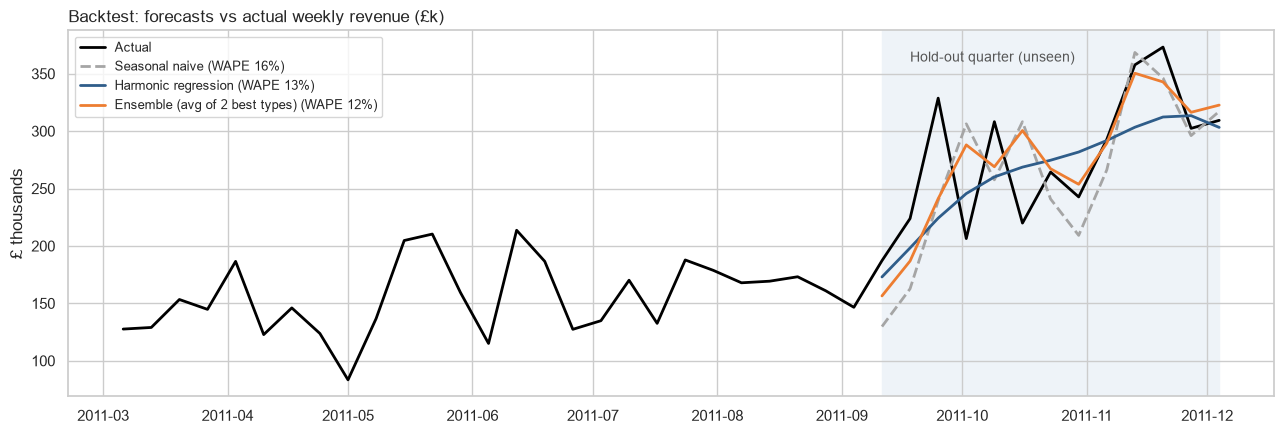

In [7]:
fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(weekly.index[-40:], weekly.iloc[-40:] / 1e3, color="black", lw=2, label="Actual")
styles = {"Seasonal naive": ("#A5A5A5", "--"), "Harmonic regression": ("#2F5D8A", "-"),
          "Ensemble (avg of 2 best types)": ("#ED7D31", "-")}
for name, (c, ls) in styles.items():
    ax.plot(test.index, forecasts[name] / 1e3, color=c, ls=ls, lw=2, label=f"{name} (WAPE {bt.loc[name, 'WAPE %']:.0f}%)")
ax.axvspan(test.index[0], test.index[-1], color="#EEF3F8", zorder=0)
ax.text(test.index[1], ax.get_ylim()[1] * 0.93, "Hold-out quarter (unseen)", fontsize=10, color="#555")
ax.set_title("Backtest: forecasts vs actual weekly revenue (£k)", loc="left"); ax.set_ylabel("£ thousands"); ax.legend(loc="upper left", fontsize=9)
plt.tight_layout(); plt.savefig(FIGS / "06_backtest.png", dpi=150); plt.show()

## 5. Forecast the next quarter (with uncertainty)
Refit the harmonic regression on **all** data and forecast 13 weeks ahead (mid-Dec 2011 → early Mar 2012).

> 📘 **Prediction intervals** say "we're 80% / 95% confident the actual will land in this range". A single number with no range is a red flag in finance. Senior management needs to know the downside scenario.

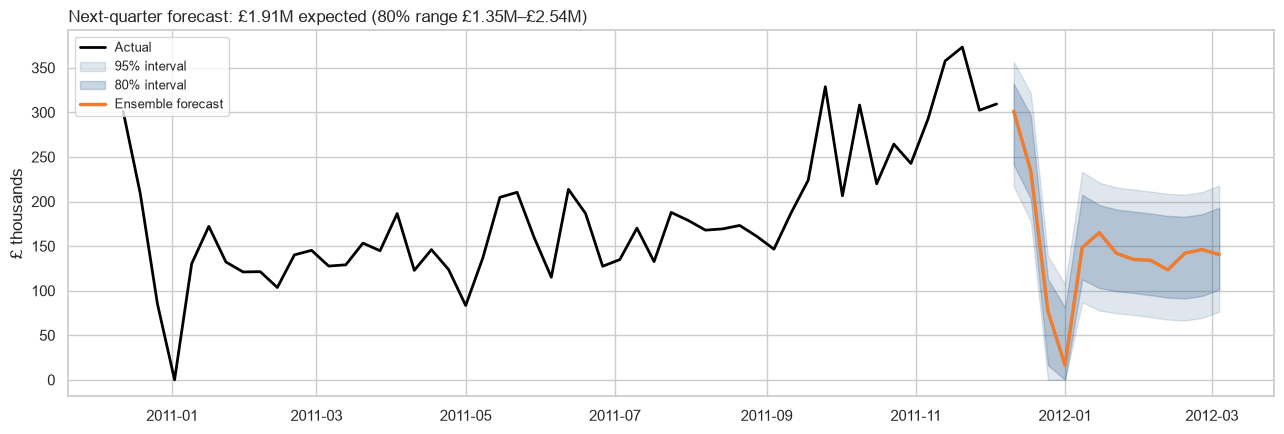

,Forecast,Lower80,Upper80,Lower95,Upper95,SeasonalNaiveGrowth,Ensemble
2011-12-11,286691.0,241220.0,332161.0,216719.0,356662.0,315780.0,301235.0
2011-12-18,249835.0,203090.0,296581.0,177902.0,321769.0,218811.0,234323.0
2011-12-25,64656.0,16385.0,112926.0,0.0,138936.0,89321.0,76988.0
2012-01-01,32753.0,0.0,80941.0,0.0,106906.0,0.0,16376.0
2012-01-08,160106.0,112533.0,207679.0,86899.0,233313.0,136643.0,148374.0
2012-01-15,149507.0,102944.0,196070.0,77855.0,221160.0,180544.0,165026.0
2012-01-22,145203.0,99337.0,191070.0,74623.0,215784.0,138607.0,141905.0
2012-01-29,143111.0,97423.0,188800.0,72804.0,213418.0,126900.0,135006.0
2012-02-05,140716.0,94952.0,186481.0,70293.0,211140.0,127280.0,133998.0
2012-02-12,138050.0,92226.0,183874.0,67535.0,208566.0,108619.0,123335.0


In [8]:
final = sm.OLS(weekly, design(weekly.index, K)).fit()
future_idx = pd.date_range(weekly.index[-1] + pd.Timedelta(weeks=1), periods=H, freq="W-SUN")
pred = final.get_prediction(design(future_idx, K))
fc = pd.DataFrame({
    "Forecast": pred.predicted_mean,
    "Lower80": pred.conf_int(obs=True, alpha=0.2)[:, 0], "Upper80": pred.conf_int(obs=True, alpha=0.2)[:, 1],
    "Lower95": pred.conf_int(obs=True, alpha=0.05)[:, 0], "Upper95": pred.conf_int(obs=True, alpha=0.05)[:, 1],
}, index=future_idx).clip(lower=0)
# Ensemble with seasonal-naive × growth for the point forecast (as in the backtest)
recent_growth = weekly.iloc[-13:].sum() / lag52.loc[weekly.index[-13:]].sum()
fc["SeasonalNaiveGrowth"] = weekly.reindex(future_idx - pd.Timedelta(weeks=52)).values * recent_growth
fc["Ensemble"] = (fc["Forecast"] + fc["SeasonalNaiveGrowth"]) / 2

fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(weekly.index[-52:], weekly.iloc[-52:] / 1e3, color="black", lw=2, label="Actual")
ax.fill_between(fc.index, fc["Lower95"] / 1e3, fc["Upper95"] / 1e3, color="#2F5D8A", alpha=.15, label="95% interval")
ax.fill_between(fc.index, fc["Lower80"] / 1e3, fc["Upper80"] / 1e3, color="#2F5D8A", alpha=.25, label="80% interval")
ax.plot(fc.index, fc["Ensemble"] / 1e3, color="#ED7D31", lw=2.5, label="Ensemble forecast")
ax.set_title(f"Next-quarter forecast: £{fc['Ensemble'].sum()/1e6:.2f}M expected "
             f"(80% range £{fc['Lower80'].sum()/1e6:.2f}M–£{fc['Upper80'].sum()/1e6:.2f}M)", loc="left")
ax.set_ylabel("£ thousands"); ax.legend(loc="upper left", fontsize=9)
plt.tight_layout(); plt.savefig(FIGS / "06_forecast.png", dpi=150); plt.show()
fc.round(0)

*Note:* the quarterly range above is a simple sum of weekly bounds, which is **conservative** (it assumes every week misses in the same direction). A statistician would simulate the combined error; for a management summary the conservative range is acceptable.

## 6. Export for Power BI (actuals + backtest + forecast in one table)

In [9]:
out = pd.DataFrame({"WeekEnding": weekly.index, "Actual": weekly.values})
bt_df = pd.DataFrame({"WeekEnding": test.index, "Backtest_Harmonic": forecasts["Harmonic regression"],
                      "Backtest_Ensemble": forecasts["Ensemble (avg of 2 best types)"]})
fut = fc.reset_index(names="WeekEnding")[["WeekEnding", "Ensemble", "Lower80", "Upper80", "Lower95", "Upper95"]] \
        .rename(columns={"Ensemble": "Forecast"})
out = out.merge(bt_df, on="WeekEnding", how="left")
out = pd.concat([out, fut], ignore_index=True)
out.to_csv(PROCESSED / "weekly_forecast.csv", index=False)
bt.round(2).to_csv(PROCESSED / "forecast_backtest_metrics.csv")
print(f"Saved weekly_forecast.csv ({len(out)} rows) and forecast_backtest_metrics.csv")

Saved weekly_forecast.csv (118 rows) and forecast_backtest_metrics.csv


## ✅ Key takeaways
1. **Always beat a baseline:** the naive forecast is ~45% off; seasonal models cut error to the mid-teens.
2. Harmonic regression captures yearly seasonality from just 2 years of data; K chosen by **AIC on training data** (no snooping).
3. An **ensemble** of a statistical model and a seasonal-growth rule gives a robust point forecast.
4. Forecasts are communicated **with ranges**, not single numbers.

**Assumptions & limitations:** only 2 years of history (one repeat of each season); no external drivers (promotions, macro-economy, pricing); the shutdown timing is assumed to repeat each year; intervals assume errors are roughly normal and independent.